# 03 - Modeling: Defect Detection Granulasi BFTP

Notebook ini berfokus pada tahap modeling untuk mendeteksi batch granulasi yang berpotensi mengalami defect berdasarkan parameter proses produksi.

## Pendekatan Modeling

Notebook ini menggunakan beberapa pendekatan:

1. **Rule-Based Defect Reasoning**  
   Digunakan untuk memberikan alasan kenapa suatu batch dikategorikan berisiko defect berdasarkan batasan dari EDA.

2. **Isolation Forest**  
   Digunakan sebagai pendekatan anomaly detection tanpa label.

3. **Random Forest Classifier**  
   Digunakan sebagai model supervised utama karena cocok untuk data tabular dan dapat memberikan feature importance.

4. **Gradient Boosting Classifier**  
   Digunakan sebagai model supervised pembanding untuk melihat performa pendekatan boosting.

# 0. Import Library

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, IsolationForest
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

import joblib

sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.05)

RANDOM_STATE = 42

os.makedirs("models", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

print("Library berhasil diimport.")
model_comparison = None

Library berhasil diimport.


## 1. Load Dataset Hasil Preprocessing

In [2]:
DATA_PATH = "outputs/dataset_clean.csv"

df = pd.read_csv(DATA_PATH, low_memory=False)

print("Dataset berhasil dimuat.")
print(f"Jumlah baris  : {df.shape[0]}")
print(f"Jumlah kolom  : {df.shape[1]}")

display(df.head())

Dataset berhasil dimuat.
Jumlah baris  : 46
Jumlah kolom  : 135


,material_desc,batch_ke,lapis1_warna,cb1_bulan,cb1_shift,cb1_line,cb1_jml_decoct_kg,cb1_suhu_lot1_1,cb1_suhu_lot1_2,cb1_suhu_lot2_1,...,cb2_suhu_tinggi,no_batch_num,lapis1_warna_enc,lapis2_warna_enc,cb1_bulan_num,cb2_bulan_num,cb1_line_enc,cb2_line_enc,ck1_keterangan_selesai,ck2_keterangan_selesai
0,BODREX FLU & BATUK PE/4'S,1.0,Orange,DESEMBER,1,CB 1,76.0,71.6,71.2,71.9,...,0,0,0,0,12,12,0,1,1,1
1,BODREX FLU & BATUK PE/4'S,5.5,Orange,DESEMBER,1,CB 1,114.0,80.4,80.9,71.1,...,0,0,0,0,12,0,0,-1,1,0
2,BODREX FLU & BATUK PE/4'S,2.0,Orange,DESEMBER,1,CB 1,76.0,71.3,71.5,71.0,...,0,0,0,0,12,12,0,1,1,1
3,BODREX FLU & BATUK PE/4'S,5.5,Orange,DESEMBER,1,CB 1,104.0,80.3,80.8,74.1,...,0,0,0,0,12,0,0,-1,1,0
4,BODREX FLU & BATUK PE/4'S,3.0,Orange,DESEMBER,1,CB 1,76.0,72.5,71.4,70.2,...,0,0,0,0,12,12,0,1,1,1


In [3]:
print("Informasi dataset:")
df.info()

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46 entries, 0 to 45
Columns: 135 entries, material_desc to ck2_keterangan_selesai
dtypes: float64(96), int64(30), object(9)
memory usage: 48.6+ KB


In [4]:
missing_summary = (
    df.isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "column", 0: "missing_count"})
)

missing_summary["missing_percentage"] = (
    missing_summary["missing_count"] / len(df) * 100
).round(2)

missing_summary = missing_summary.sort_values("missing_count", ascending=False)

display(missing_summary.head(20))

,column,missing_count,missing_percentage
0,material_desc,0,0.0
85,cb2_outlet_lot1_ph1,0,0.0
99,cb1_ka3_ekstrem,0,0.0
98,cb1_ka2_ekstrem,0,0.0
97,cb1_ka1_ekstrem,0,0.0
96,is_defect,0,0.0
95,ck2_keterangan,0,0.0
94,cb2_no_ayakan_frewitt,0,0.0
93,cb2_no_ayakan_alex,0,0.0
92,cb2_waktu_lot4_ph1,0,0.0


## 2. Validasi Label Target Defect

In [5]:
# 2. Validasi Label Target Defect

TARGET = "is_defect"

assert TARGET in df.columns, f"Kolom target '{TARGET}' tidak ditemukan pada dataset."


if "row_no" not in df.columns:
    df["row_no"] = np.arange(1, len(df) + 1)

df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce")


missing_target = df[TARGET].isna().sum()
assert missing_target == 0, f"Terdapat {missing_target} nilai kosong pada kolom {TARGET}."


df[TARGET] = df[TARGET].astype(int)


unique_labels = sorted(df[TARGET].unique().tolist())
assert set(unique_labels).issubset({0, 1}), (
    f"Label {TARGET} harus 0/1, tetapi ditemukan: {unique_labels}"
)


total_defect = int(df[TARGET].sum())
total_normal = int((df[TARGET] == 0).sum())
defect_rows = df.loc[df[TARGET] == 1, "row_no"].tolist()

print("Validasi label target berhasil.")
print(f"Total normal : {total_normal}")
print(f"Total defect : {total_defect}")
print("Row_no defect pada dataset ini:", defect_rows)

# Validasi khusus hanya untuk dataset saat ini
EXPECTED_DEFECT_ROWS_CURRENT_DATASET = [2, 4, 10, 12, 14, 17, 31, 36, 42, 43, 44]

if len(df) == 46:
    assert defect_rows == EXPECTED_DEFECT_ROWS_CURRENT_DATASET, (
        "Row_no defect pada dataset saat ini tidak sesuai validasi manual."
    )
    assert total_defect == 11, "Jumlah defect pada dataset saat ini harus 11."

print("Label is_defect digunakan sebagai target model tanpa overwrite berdasarkan row_no.")

Validasi label target berhasil.
Total normal : 35
Total defect : 11
Row_no defect pada dataset ini: [2, 4, 10, 12, 14, 17, 31, 36, 42, 43, 44]
Label is_defect digunakan sebagai target model tanpa overwrite berdasarkan row_no.


In [6]:
defect_check = df.loc[
    df["is_defect"] == 1,
    ["row_no", "is_defect"]
].copy()

display(defect_check)

print("Jumlah defect:", len(defect_check))
print("Row_no defect:", defect_check["row_no"].tolist())

,row_no,is_defect
1,2,1
3,4,1
9,10,1
11,12,1
13,14,1
16,17,1
30,31,1
35,36,1
41,42,1
42,43,1


Jumlah defect: 11
Row_no defect: [2, 4, 10, 12, 14, 17, 31, 36, 42, 43, 44]


## 3. Distribusi Label Target

Setelah label target divalidasi, dilakukan pengecekan distribusi kelas normal dan defect. Distribusi label penting untuk mengetahui apakah dataset seimbang atau tidak. Dalam kasus ini, jumlah batch normal lebih banyak dibandingkan batch defect. Oleh karena itu, model supervised menggunakan pendekatan yang memperhatikan class imbalance, seperti `class_weight='balanced'` pada Random Forest.

In [7]:
# Distribusi label target berdasarkan kolom is_defect dari dataset
label_summary = pd.DataFrame({
    "kategori": ["Normal", "Defect"],
    "jumlah": [
        int((df["is_defect"] == 0).sum()),
        int((df["is_defect"] == 1).sum())
    ],
    "persentase": [
        round((df["is_defect"] == 0).mean() * 100, 2),
        round((df["is_defect"] == 1).mean() * 100, 2)
    ]
})

display(label_summary)
print("Row_no defect pada dataset ini:")
print(df.loc[df["is_defect"] == 1, "row_no"].tolist())

,kategori,jumlah,persentase
0,Normal,35,76.09
1,Defect,11,23.91


Row_no defect pada dataset ini:
[2, 4, 10, 12, 14, 17, 31, 36, 42, 43, 44]


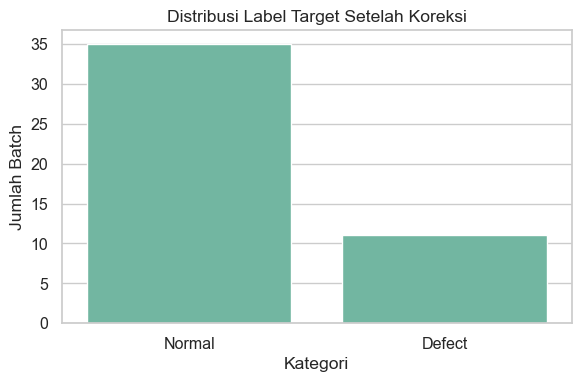

In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="is_defect")
plt.xticks([0, 1], ["Normal", "Defect"])
plt.title("Distribusi Label Target Setelah Koreksi")
plt.xlabel("Kategori")
plt.ylabel("Jumlah Batch")
plt.tight_layout()
plt.savefig("outputs/distribusi_label.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Rule-Based Defect Reasoning

Berdasarkan hasil EDA, batch dapat dikategorikan berisiko defect apabila memiliki indikasi ketidaksesuaian proses, seperti:

1. Suhu decoct terlalu tinggi.
2. Kadar Air atau KA terlalu rendah, terlalu tinggi, atau ekstrem.
3. Yield menyimpang dari rentang normal.
4. Batch memiliki label defect berdasarkan kolom `is_defect` dari dataset.

Rule-based reasoning pada notebook ini digunakan untuk membantu interpretasi hasil, bukan sebagai pengganti model machine learning.

In [9]:
def get_value(row, col):
    if col in row.index and pd.notna(row[col]):
        return row[col]
    return None


def generate_defect_reasons(row):
    reasons = []

    
    # 1. Suhu Decoct Rata-rata
    suhu_rata_cols = [
        c for c in row.index
        if "suhu" in c.lower()
        and "rata" in c.lower()
    ]

    for col in suhu_rata_cols:
        v = get_value(row, col)
        if v is not None and isinstance(v, (int, float, np.number)):
            if v > 75:
                reasons.append(f"{col} tinggi ({v:.2f}°C > 75°C)")

    
    # 2. Suhu Individual
    suhu_cols = [
        c for c in row.index
        if "suhu" in c.lower()
        and "rata" not in c.lower()
        and "std" not in c.lower()
    ]

    for col in suhu_cols:
        v = get_value(row, col)
        if v is not None and isinstance(v, (int, float, np.number)):
            if v > 75:
                reasons.append(f"{col} tinggi ({v:.2f}°C > 75°C)")


    # 3. Kadar Air / KA
    ka_cols = [
        c for c in row.index
        if c.lower() in [
            "cb1_ka1", "cb1_ka2", "cb1_ka3", "cb1_ka4", "cb1_ka5", "cb1_ka6",
            "cb2_ka1", "cb2_ka2", "cb2_ka3", "cb2_ka4", "cb2_ka5", "cb2_ka6",
            "ka1", "ka2", "ka3", "ka4", "ka5", "ka6",
            "cb1_rata_ka", "cb2_rata_ka", "rata_ka"
        ]
    ]

    for col in ka_cols:
        v = get_value(row, col)
        if v is not None and isinstance(v, (int, float, np.number)):
            if v > 10:
                reasons.append(f"{col} ekstrem ({v:.2f}% > 10%)")
            elif v > 5.5:
                reasons.append(f"{col} tinggi ({v:.2f}% > 5.5%)")
            elif v < 3.0:
                reasons.append(f"{col} rendah ({v:.2f}% < 3.0%)")


    # 4. Jumlah KA Ekstrem
    v = get_value(row, "ka_ekstrem_count")
    if v is not None and isinstance(v, (int, float, np.number)):
        if v > 0:
            reasons.append(f"Terdapat {int(v)} indikator KA ekstrem")


    # 5. Yield
    yield_cols = [
        "cb1_pct_yield",
        "ck1_pct_yield",
        "cb2_pct_yield"
    ]

    for col in yield_cols:
        v = get_value(row, col)
        if v is not None and isinstance(v, (int, float, np.number)):
            if v == 0:
                continue
            elif v < 99:
                reasons.append(f"{col} rendah ({v:.2f}% < 99%)")
            elif v > 103.1:
                reasons.append(f"{col} tinggi ({v:.2f}% > 103.1%)")

 
    # 6. Keterangan Proses
    ket_cols = [
        c for c in row.index
        if "keterangan" in c.lower()
    ]

    for col in ket_cols:
        v = row[col]

        if pd.isna(v):
            reasons.append(f"{col} kosong")
        elif isinstance(v, str) and v.strip().upper() not in ["SELESAI", "DONE"]:
            reasons.append(f"{col} bukan status selesai: {v}")


    # 7. Default Reason
    if len(reasons) == 0:
        reasons.append(
            "Tidak ada pelanggaran threshold utama, tetapi termasuk defect berdasarkan label is_defect dari dataset."
        )

    return " | ".join(reasons)


df["defect_reasons"] = df.apply(
    lambda row: generate_defect_reasons(row) if row["is_defect"] == 1 else "-",
    axis=1
)

display(df.loc[df["is_defect"] == 1, ["row_no", "is_defect", "defect_reasons"]])

,row_no,is_defect,defect_reasons
1,2,1,cb1_suhu_rata tinggi (78.25°C > 75°C) | cb1_su...
3,4,1,cb1_suhu_rata tinggi (77.32°C > 75°C) | cb1_su...
9,10,1,cb1_suhu_rata tinggi (78.00°C > 75°C) | cb1_su...
11,12,1,cb1_suhu_rata tinggi (78.05°C > 75°C) | cb1_su...
13,14,1,cb1_suhu_rata tinggi (79.45°C > 75°C) | cb1_su...
16,17,1,cb1_suhu_rata tinggi (76.80°C > 75°C) | cb1_su...
30,31,1,cb1_suhu_lot1_2 tinggi (75.40°C > 75°C) | cb1_...
35,36,1,cb1_suhu_lot1_2 tinggi (75.90°C > 75°C) | cb1_...
41,42,1,cb1_suhu_rata tinggi (76.12°C > 75°C) | cb1_su...
42,43,1,cb1_suhu_rata tinggi (75.15°C > 75°C) | cb1_su...


## 5. Pemilihan Fitur Modeling

Fitur modeling dipilih dari kolom hasil preprocessing.

Beberapa kolom tidak digunakan sebagai fitur karena dapat menyebabkan data leakage atau tidak relevan untuk training model, seperti:
- `is_defect`
- `row_no`
- kolom prediksi model sebelumnya
- kolom output seperti status, prediction, probability, dan consensus label
- kolom penjelasan teks panjang seperti `defect_reasons`

Fitur numerik digunakan langsung setelah missing value diisi dengan median.  
Fitur kategorikal diubah menjadi nilai numerik menggunakan `LabelEncoder`.

In [10]:
TARGET = "is_defect"

# Kolom yang tidak boleh digunakan sebagai fitur
# karena merupakan target, ID, output prediksi, atau berpotensi menyebabkan data leakage
exclude_cols = [
    TARGET,
    "is_defect_lama",
    "row_no",
    "excel_row",
    "defect_reasons",
    "consensus_label",
    "consensus_defect",
    "model_consensus_label",
    "model_consensus_pred",
    "rf_status",
    "gb_status",
    "if_status",
    "IF_Pred",
    "IF_Anomaly_Score"
]

# Keyword yang menandakan kolom hasil prediksi/output,
# sehingga tidak boleh masuk ke fitur training
exclude_keywords = [
    "pred",
    "prediction",
    "proba",
    "probability",
    "status",
    "label",
    "consensus"
]

candidate_cols = []

for col in df.columns:
    if col in exclude_cols:
        continue
    if any(keyword in col.lower() for keyword in exclude_keywords):
        continue
    candidate_cols.append(col)

# Pisahkan fitur numerik dan kategorikal
numeric_cols = df[candidate_cols].select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_cols = df[candidate_cols].select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Jumlah kandidat fitur:", len(candidate_cols))
print("Jumlah fitur numerik:", len(numeric_cols))
print("Jumlah fitur kategorikal:", len(categorical_cols))

print("\nContoh fitur numerik:")
print(numeric_cols[:20])

print("\nContoh fitur kategorikal:")
print(categorical_cols[:20])

Jumlah kandidat fitur: 134
Jumlah fitur numerik: 125
Jumlah fitur kategorikal: 9

Contoh fitur numerik:
['batch_ke', 'cb1_shift', 'cb1_jml_decoct_kg', 'cb1_suhu_lot1_1', 'cb1_suhu_lot1_2', 'cb1_suhu_lot2_1', 'cb1_suhu_lot2_2', 'cb1_suhu_diosna_lot1_1', 'cb1_suhu_diosna_lot1_2', 'cb1_suhu_diosna_lot2_1', 'cb1_suhu_diosna_lot2_2', 'cb1_jml_granul_kg', 'cb1_teoritis_granul', 'cb1_pct_yield', 'cb1_ka1', 'cb1_ka2', 'cb1_rata_ka', 'cb1_mixer1', 'cb1_mixer2', 'cb1_chopper1']

Contoh fitur kategorikal:
['material_desc', 'lapis1_warna', 'cb1_bulan', 'cb1_line', 'ck1_keterangan', 'lapis2_warna', 'cb2_bulan', 'cb2_line', 'ck2_keterangan']


In [11]:
df_model = df.copy()
label_encoders = {}

# Encoding fitur kategorikal
for col in categorical_cols:
    le = LabelEncoder()
    df_model[col] = df_model[col].fillna("UNKNOWN").astype(str)
    df_model[col] = le.fit_transform(df_model[col])
    label_encoders[col] = le

# Handling missing value fitur numerik
for col in numeric_cols:
    df_model[col] = pd.to_numeric(df_model[col], errors="coerce")
    median_value = df_model[col].median()
    df_model[col] = df_model[col].fillna(median_value)

FEATURE_COLS = numeric_cols + categorical_cols

X = df_model[FEATURE_COLS].copy()
y = df_model[TARGET].astype(int).copy()

print("Shape fitur X:", X.shape)
print("Shape target y:", y.shape)

print("\nDistribusi target:")
display(y.value_counts().rename(index={0: "Normal", 1: "Defect"}))

Shape fitur X: (46, 134)
Shape target y: (46,)

Distribusi target:


is_defect
Normal    35
Defect    11
Name: count, dtype: int64

## 6. Train-Test Split dan Scaling

Dataset dibagi menjadi data training dan testing menggunakan stratified split agar proporsi kelas normal dan defect tetap terjaga.

Scaling dilakukan menggunakan `StandardScaler`, terutama untuk model berbasis anomaly detection seperti Isolation Forest.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_all_scaled = scaler.transform(X)

print("Shape X_train:", X_train.shape)
print("Shape X_test :", X_test.shape)

print("\nDistribusi label train:")
display(y_train.value_counts().rename(index={0: "Normal", 1: "Defect"}))

print("\nDistribusi label test:")
display(y_test.value_counts().rename(index={0: "Normal", 1: "Defect"}))

Shape X_train: (34, 134)
Shape X_test : (12, 134)

Distribusi label train:


is_defect
Normal    26
Defect     8
Name: count, dtype: int64


Distribusi label test:


is_defect
Normal    9
Defect    3
Name: count, dtype: int64

## 7. Fungsi Evaluasi Model

Fungsi evaluasi dibuat agar hasil setiap model dapat ditampilkan secara konsisten.

Metrik yang digunakan adalah:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Average Precision Score

Pada kasus defect detection, recall dan F1-score menjadi metrik penting karena defect yang tidak terdeteksi dapat berdampak pada kualitas proses produksi.

In [13]:
def evaluate_model(model_name, y_true, y_pred, y_proba=None):
    print(f"Evaluation Result: {model_name}")
    print("-" * 60)
    print(classification_report(
        y_true,
        y_pred,
        target_names=["Normal", "Defect"],
        zero_division=0
    ))

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    result = {
        "model": model_name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1
    }

    if y_proba is not None and len(np.unique(y_true)) > 1:
        result["roc_auc"] = roc_auc_score(y_true, y_proba)
        result["average_precision"] = average_precision_score(y_true, y_proba)
    else:
        result["roc_auc"] = np.nan
        result["average_precision"] = np.nan

    return result


def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Normal", "Defect"],
        yticklabels=["Normal", "Defect"]
    )
    plt.title(title)
    plt.xlabel("Prediksi")
    plt.ylabel("Aktual")
    plt.tight_layout()
    plt.show()

## 8. Model 1: Isolation Forest

Isolation Forest digunakan sebagai pendekatan unsupervised anomaly detection.

Model ini tidak menggunakan label defect saat training, melainkan mendeteksi data yang memiliki pola berbeda dari mayoritas batch. Pendekatan ini digunakan sebagai pembanding terhadap model supervised.

Evaluation Result: Isolation Forest
------------------------------------------------------------
              precision    recall  f1-score   support

      Normal       1.00      0.89      0.94         9
      Defect       0.75      1.00      0.86         3

    accuracy                           0.92        12
   macro avg       0.88      0.94      0.90        12
weighted avg       0.94      0.92      0.92        12



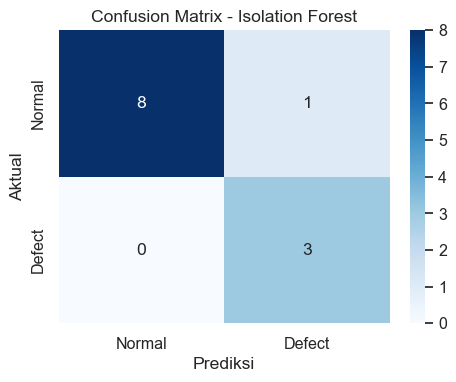

In [14]:
contamination_rate = y.mean()
contamination_rate = max(0.01, min(contamination_rate, 0.5))

iso_model = IsolationForest(
    n_estimators=300,
    contamination=contamination_rate,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

iso_model.fit(X_train_scaled)

iso_pred_test = (iso_model.predict(X_test_scaled) == -1).astype(int)
iso_pred_all = (iso_model.predict(X_all_scaled) == -1).astype(int)
iso_score_all = iso_model.score_samples(X_all_scaled)

iso_result = evaluate_model(
    model_name="Isolation Forest",
    y_true=y_test,
    y_pred=iso_pred_test
)

plot_confusion_matrix(
    y_true=y_test,
    y_pred=iso_pred_test,
    title="Confusion Matrix - Isolation Forest"
)

## 9. Model 2: Random Forest Classifier

Random Forest digunakan sebagai model supervised utama.

Model ini dipilih karena:

- Cocok untuk data tabular.
- Relatif stabil pada dataset berukuran kecil.
- Dapat menangani class imbalance menggunakan `class_weight='balanced'`.
- Dapat memberikan feature importance untuk interpretasi.

Evaluation Result: Random Forest
------------------------------------------------------------
              precision    recall  f1-score   support

      Normal       0.90      1.00      0.95         9
      Defect       1.00      0.67      0.80         3

    accuracy                           0.92        12
   macro avg       0.95      0.83      0.87        12
weighted avg       0.92      0.92      0.91        12



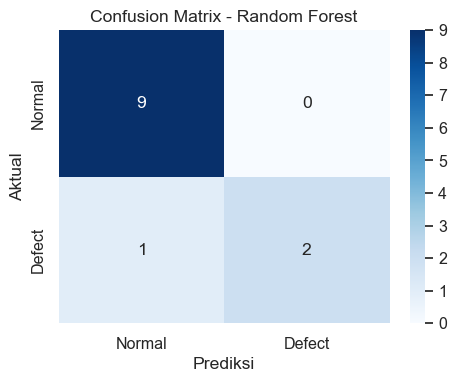

In [15]:
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred_test = rf_model.predict(X_test)
rf_proba_test = rf_model.predict_proba(X_test)[:, 1]

rf_result = evaluate_model(
    model_name="Random Forest",
    y_true=y_test,
    y_pred=rf_pred_test,
    y_proba=rf_proba_test
)

plot_confusion_matrix(
    y_true=y_test,
    y_pred=rf_pred_test,
    title="Confusion Matrix - Random Forest"
)

## 10. Model 3: Gradient Boosting Classifier

Gradient Boosting digunakan sebagai model supervised pembanding.

Model ini bekerja dengan membangun model secara bertahap, di mana setiap model baru berusaha memperbaiki kesalahan dari model sebelumnya. Pendekatan ini membantu melihat apakah metode boosting dapat memberikan performa yang lebih baik dalam mendeteksi batch defect.

Evaluation Result: Gradient Boosting
------------------------------------------------------------
              precision    recall  f1-score   support

      Normal       1.00      0.89      0.94         9
      Defect       0.75      1.00      0.86         3

    accuracy                           0.92        12
   macro avg       0.88      0.94      0.90        12
weighted avg       0.94      0.92      0.92        12



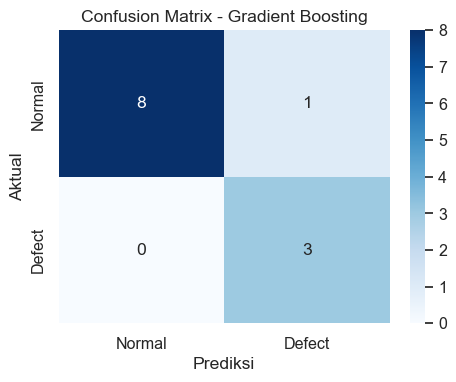

In [16]:
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=RANDOM_STATE
)

gb_model.fit(X_train, y_train)

gb_pred_test = gb_model.predict(X_test)
gb_proba_test = gb_model.predict_proba(X_test)[:, 1]

gb_result = evaluate_model(
    model_name="Gradient Boosting",
    y_true=y_test,
    y_pred=gb_pred_test,
    y_proba=gb_proba_test
)

plot_confusion_matrix(
    y_true=y_test,
    y_pred=gb_pred_test,
    title="Confusion Matrix - Gradient Boosting"
)

## 11. Perbandingan Performa Model

Pada bagian ini, performa setiap model dibandingkan menggunakan beberapa metrik evaluasi, yaitu accuracy, precision, recall, F1-score, ROC-AUC, dan average precision.

Model yang dibandingkan terdiri dari Isolation Forest, Random Forest Classifier, dan Gradient Boosting Classifier. Isolation Forest digunakan sebagai pendekatan anomaly detection, sedangkan Random Forest dan Gradient Boosting digunakan sebagai model supervised learning.

Dalam konteks defect detection, metrik recall dan F1-score menjadi perhatian utama. Recall penting karena menunjukkan kemampuan model dalam mengenali batch defect. Jika recall rendah, artinya masih terdapat batch defect yang tidak berhasil terdeteksi oleh model.

Oleh karena itu, pemilihan model tidak hanya dilihat dari accuracy, tetapi juga dari kemampuan model dalam mengenali kelas defect.

Tabel Perbandingan Performa Model:


,model,accuracy,precision,recall,f1_score,roc_auc,average_precision
0,Isolation Forest,0.916667,0.75,1.000000,0.857143,NaN,NaN
1,Gradient Boosting,0.916667,0.75,1.000000,0.857143,0.944444,0.75
2,Random Forest,0.916667,1.00,0.666667,0.800000,1.000000,1.00



Model dengan performa terbaik berdasarkan recall dan F1-score:
Model    : Isolation Forest
Recall   : 1.0000
F1-score : 0.8571

Catatan:
Pemilihan model mempertimbangkan recall karena pada kasus defect detection, defect yang tidak terdeteksi lebih berisiko dibandingkan normal yang salah terdeteksi sebagai defect.


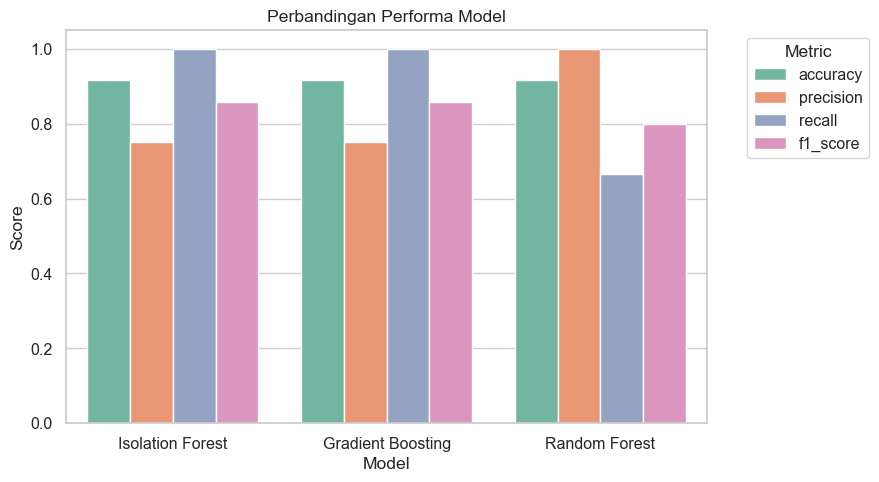

In [17]:
# 11. Perbandingan Performa Model
# Pastikan hasil evaluasi dari 3 model sudah tersedia
required_results = {
    "Isolation Forest": "iso_result",
    "Random Forest": "rf_result",
    "Gradient Boosting": "gb_result"
}

missing_results = [
    var_name for model_name, var_name in required_results.items()
    if var_name not in globals()
]

if missing_results:
    raise NameError(
        "Hasil evaluasi model belum lengkap. "
        f"Variabel yang belum ada: {missing_results}. "
        "Jalankan dulu cell Isolation Forest, Random Forest, dan Gradient Boosting sebelum bagian ini."
    )

# Buat tabel perbandingan model dari hasil evaluasi
comparison_df = pd.DataFrame([
    iso_result,
    rf_result,
    gb_result
])

# Rapikan nama kolom agar konsisten
comparison_df.columns = (
    comparison_df.columns
    .str.lower()
    .str.replace("-", "_", regex=False)
    .str.replace(" ", "_", regex=False)
)

# Pastikan kolom model ada
if "model" not in comparison_df.columns:
    raise KeyError(
        "Kolom 'model' tidak ditemukan pada tabel perbandingan. "
        "Cek kembali output dari fungsi evaluate_model()."
    )

# Pastikan kolom metrik tersedia
required_metric_cols = ["accuracy", "precision", "recall", "f1_score"]

missing_metric_cols = [
    col for col in required_metric_cols
    if col not in comparison_df.columns
]

if missing_metric_cols:
    raise KeyError(
        f"Kolom metrik belum lengkap: {missing_metric_cols}. "
        "Pastikan fungsi evaluate_model() menghasilkan accuracy, precision, recall, dan f1_score."
    )

# Ubah metrik menjadi numerik
metric_cols = [
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc",
    "average_precision"
]

for col in metric_cols:
    if col in comparison_df.columns:
        comparison_df[col] = pd.to_numeric(comparison_df[col], errors="coerce")

# Urutkan berdasarkan recall dan f1_score
comparison_df = comparison_df.sort_values(
    by=["recall", "f1_score"],
    ascending=False
).reset_index(drop=True)

# Simpan juga ke variabel model_comparison agar bisa dipakai cell lain kalau diperlukan
model_comparison = comparison_df.copy()

print("Tabel Perbandingan Performa Model:")
display(model_comparison)

# Ambil model terbaik berdasarkan recall dan f1_score
best_model_row = model_comparison.iloc[0]

print("\nModel dengan performa terbaik berdasarkan recall dan F1-score:")
print(f"Model    : {best_model_row['model']}")
print(f"Recall   : {best_model_row['recall']:.4f}")
print(f"F1-score : {best_model_row['f1_score']:.4f}")

print("\nCatatan:")
print("Pemilihan model mempertimbangkan recall karena pada kasus defect detection, defect yang tidak terdeteksi lebih berisiko dibandingkan normal yang salah terdeteksi sebagai defect.")

# Visualisasi perbandingan model
comparison_melted = model_comparison.melt(
    id_vars="model",
    value_vars=["accuracy", "precision", "recall", "f1_score"],
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=comparison_melted,
    x="model",
    y="score",
    hue="metric"
)

plt.title("Perbandingan Performa Model")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("outputs/perbandingan_model.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretasi Hasil Evaluasi Model

Berdasarkan hasil perbandingan model pada data test, Gradient Boosting memperoleh nilai recall terbaik dibandingkan model lainnya. Hal ini menunjukkan bahwa Gradient Boosting mampu mengenali seluruh data defect pada data test.

Random Forest tetap digunakan sebagai model supervised utama karena cocok untuk data tabular dan dapat memberikan feature importance. Isolation Forest digunakan sebagai pendekatan anomaly detection untuk membantu melihat pola anomali pada dataset.

Dengan demikian, hasil prediksi model pada notebook ini digunakan sebagai pendukung analisis, bukan sebagai pengganti label defect manual. Label final tetap mengacu pada kolom `is_defect` dari dataset.

## 12. Cross Validation

Karena jumlah data relatif kecil, cross validation dilakukan untuk melihat kestabilan performa model.

Cross validation menggunakan Stratified K-Fold agar proporsi kelas normal dan defect tetap terjaga pada setiap fold.

In [18]:
min_class_count = y.value_counts().min()
n_splits = min(5, min_class_count)

print(f"Jumlah fold yang digunakan: {n_splits}")

if n_splits >= 2:
    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    rf_cv_f1 = cross_val_score(
        rf_model,
        X,
        y,
        cv=skf,
        scoring="f1",
        n_jobs=-1
    )

    gb_cv_f1 = cross_val_score(
        gb_model,
        X,
        y,
        cv=skf,
        scoring="f1",
        n_jobs=-1
    )

    cv_summary = pd.DataFrame({
        "model": ["Random Forest", "Gradient Boosting"],
        "cv_f1_mean": [rf_cv_f1.mean(), gb_cv_f1.mean()],
        "cv_f1_std": [rf_cv_f1.std(), gb_cv_f1.std()],
        "cv_scores": [rf_cv_f1, gb_cv_f1]
    })

    display(cv_summary)

else:
    print("Cross validation tidak dapat dilakukan karena jumlah kelas minoritas terlalu sedikit.")

Jumlah fold yang digunakan: 5


,model,cv_f1_mean,cv_f1_std,cv_scores
0,Random Forest,0.833333,0.210819,"[0.5, 1.0, 1.0, 0.6666666666666666, 1.0]"
1,Gradient Boosting,0.860000,0.195959,"[0.5, 0.8, 1.0, 1.0, 1.0]"


## 13. Feature Importance

Feature importance digunakan untuk mengetahui fitur atau parameter proses yang paling berpengaruh terhadap prediksi defect.

Informasi ini membantu proses interpretasi model, sehingga hasil modeling tidak hanya berupa prediksi, tetapi juga dapat memberikan insight terkait parameter produksi yang perlu diperhatikan.

In [19]:
importance_df = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

display(importance_df.head(20))

,feature,importance
4,cb1_suhu_lot1_2,0.105752
105,cb1_suhu_rata,0.075194
107,cb1_suhu_std,0.071324
131,cb2_bulan,0.055868
114,cb1_suhu_tinggi,0.041251
6,cb1_suhu_lot2_2,0.034647
31,cb1_waktu_lot2_ph1,0.032191
32,cb1_waktu_lot2_ph2,0.026554
108,cb2_suhu_std,0.021085
13,cb1_pct_yield,0.020676


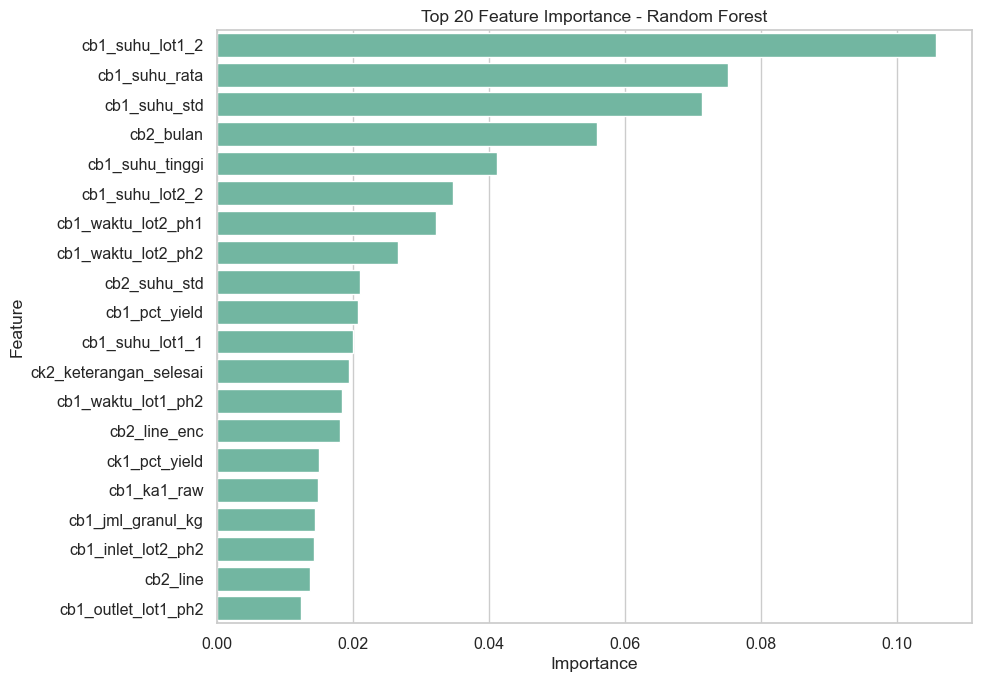

In [20]:
plt.figure(figsize=(10, 7))
sns.barplot(
    data=importance_df.head(20),
    x="importance",
    y="feature"
)
plt.title("Top 20 Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("outputs/feature_importance_rf.png", dpi=150, bbox_inches="tight")
plt.show()

## 14. Prediksi Final Seluruh Dataset

In [21]:
# Prediksi seluruh data menggunakan model yang sudah dilatih
rf_pred_all = rf_model.predict(X)
rf_proba_all = rf_model.predict_proba(X)[:, 1]

gb_pred_all = gb_model.predict(X)
gb_proba_all = gb_model.predict_proba(X)[:, 1]

# Isolation Forest menggunakan data yang sudah discaling
iso_pred_all = (iso_model.predict(X_all_scaled) == -1).astype(int)
iso_score_all = iso_model.score_samples(X_all_scaled)

# Buat dataframe output
df_output = df.copy()

# Simpan hasil prediksi masing-masing model
df_output["isolation_forest_pred"] = iso_pred_all
df_output["isolation_forest_score"] = iso_score_all

df_output["rf_pred"] = rf_pred_all
df_output["rf_proba_defect"] = rf_proba_all

df_output["gb_pred"] = gb_pred_all
df_output["gb_proba_defect"] = gb_proba_all

# Voting prediksi dari tiga model
df_output["model_vote_defect"] = (
    df_output["isolation_forest_pred"]
    + df_output["rf_pred"]
    + df_output["gb_pred"]
)

# Consensus prediction dari model
# Jika minimal 2 dari 3 model memprediksi defect, maka model_consensus_pred = 1
df_output["model_consensus_pred"] = (
    df_output["model_vote_defect"] >= 2
).astype(int)


df_output["consensus_label"] = df_output["is_defect"].map({
    0: "Normal",
    1: "Defect"
})

# Status prediksi masing-masing model
df_output["rf_status"] = df_output["rf_pred"].map({
    0: "Normal",
    1: "Defect"
})

df_output["gb_status"] = df_output["gb_pred"].map({
    0: "Normal",
    1: "Defect"
})

df_output["if_status"] = df_output["isolation_forest_pred"].map({
    0: "Normal",
    1: "Defect"
})

df_output["model_consensus_status"] = df_output["model_consensus_pred"].map({
    0: "Normal",
    1: "Defect"
})




final_defect_rows = df_output.loc[df_output["is_defect"] == 1, "row_no"].tolist()
final_defect_count = int(df_output["is_defect"].sum())

print("Final defect rows pada dataset ini:", final_defect_rows)
print("Final defect count:", final_defect_count)


EXPECTED_DEFECT_ROWS_CURRENT_DATASET = [2, 4, 10, 12, 14, 17, 31, 36, 42, 43, 44]




if len(df_output) == 46:
    assert final_defect_rows == EXPECTED_DEFECT_ROWS_CURRENT_DATASET, (
        "Baris defect final pada dataset saat ini tidak sesuai validasi manual."
    )
    assert final_defect_count == 11, (
        "Jumlah defect final pada dataset saat ini harus 11."
    )

print("Prediksi final berhasil dibuat.")
print("Label defect final tetap mengikuti kolom is_defect dari dataset, bukan dikunci berdasarkan row_no.")

# Preview output final
final_cols = [
    "row_no",
    "is_defect",
    "consensus_label",
    "rf_pred",
    "rf_proba_defect",
    "gb_pred",
    "gb_proba_defect",
    "isolation_forest_pred",
    "model_consensus_pred",
    "model_consensus_status",
    "defect_reasons"
]

display(df_output[final_cols].head(20))

Final defect rows pada dataset ini: [2, 4, 10, 12, 14, 17, 31, 36, 42, 43, 44]
Final defect count: 11
Prediksi final berhasil dibuat.
Label defect final tetap mengikuti kolom is_defect dari dataset, bukan dikunci berdasarkan row_no.


,row_no,is_defect,consensus_label,rf_pred,rf_proba_defect,gb_pred,gb_proba_defect,isolation_forest_pred,model_consensus_pred,model_consensus_status,defect_reasons
0,1,0,Normal,0,0.061937,0,0.000011,0,0,Normal,-
1,2,1,Defect,1,0.929777,1,0.999967,0,1,Defect,cb1_suhu_rata tinggi (78.25°C > 75°C) | cb1_su...
2,3,0,Normal,0,0.077852,0,0.000011,1,0,Normal,-
3,4,1,Defect,1,0.919274,1,0.999967,1,1,Defect,cb1_suhu_rata tinggi (77.32°C > 75°C) | cb1_su...
4,5,0,Normal,0,0.100221,0,0.000011,0,0,Normal,-
5,6,0,Normal,0,0.078676,0,0.000011,0,0,Normal,-
6,7,0,Normal,0,0.108587,0,0.000011,0,0,Normal,-
7,8,0,Normal,0,0.058448,0,0.000011,0,0,Normal,-
8,9,0,Normal,0,0.121108,0,0.000011,0,0,Normal,-
9,10,1,Defect,1,0.851571,1,0.999967,1,1,Defect,cb1_suhu_rata tinggi (78.00°C > 75°C) | cb1_su...


## 15. Validasi Batch Defect Final

In [22]:
final_defect_table = df_output.loc[
    df_output["is_defect"] == 1,
    final_cols
]

display(final_defect_table)

print("Jumlah defect final:", len(final_defect_table))
print("Baris defect final:", final_defect_table["row_no"].tolist())

,row_no,is_defect,consensus_label,rf_pred,rf_proba_defect,gb_pred,gb_proba_defect,isolation_forest_pred,model_consensus_pred,model_consensus_status,defect_reasons
1,2,1,Defect,1,0.929777,1,0.999967,0,1,Defect,cb1_suhu_rata tinggi (78.25°C > 75°C) | cb1_su...
3,4,1,Defect,1,0.919274,1,0.999967,1,1,Defect,cb1_suhu_rata tinggi (77.32°C > 75°C) | cb1_su...
9,10,1,Defect,1,0.851571,1,0.999967,1,1,Defect,cb1_suhu_rata tinggi (78.00°C > 75°C) | cb1_su...
11,12,1,Defect,1,0.823927,1,0.999967,1,1,Defect,cb1_suhu_rata tinggi (78.05°C > 75°C) | cb1_su...
13,14,1,Defect,1,0.937869,1,0.999967,1,1,Defect,cb1_suhu_rata tinggi (79.45°C > 75°C) | cb1_su...
16,17,1,Defect,1,0.917765,1,0.999967,1,1,Defect,cb1_suhu_rata tinggi (76.80°C > 75°C) | cb1_su...
30,31,1,Defect,0,0.445337,1,0.999967,1,1,Defect,cb1_suhu_lot1_2 tinggi (75.40°C > 75°C) | cb1_...
35,36,1,Defect,1,0.697495,1,0.999967,0,1,Defect,cb1_suhu_lot1_2 tinggi (75.90°C > 75°C) | cb1_...
41,42,1,Defect,1,0.786042,1,0.999967,1,1,Defect,cb1_suhu_rata tinggi (76.12°C > 75°C) | cb1_su...
42,43,1,Defect,1,0.894085,1,0.999967,0,1,Defect,cb1_suhu_rata tinggi (75.15°C > 75°C) | cb1_su...


Jumlah defect final: 11
Baris defect final: [2, 4, 10, 12, 14, 17, 31, 36, 42, 43, 44]


## 16. Simpan Output dan Model

Output akhir disimpan dalam bentuk file CSV agar dapat digunakan pada tahap selanjutnya, seperti dashboard, monitoring, atau dokumentasi project. Model juga disimpan dalam format `.joblib` agar dapat digunakan kembali tanpa perlu melakukan training ulang.

In [23]:
df_output.to_csv("outputs/dataset_with_predictions.csv", index=False)

joblib.dump(rf_model, "models/random_forest_defect_model.joblib")
joblib.dump(gb_model, "models/gradient_boosting_defect_model.joblib")
joblib.dump(iso_model, "models/isolation_forest_defect_model.joblib")
joblib.dump(scaler, "models/scaler.joblib")
joblib.dump(label_encoders, "models/label_encoders.joblib")
joblib.dump(FEATURE_COLS, "models/feature_columns.joblib")

print("Output dan model berhasil disimpan:")
print("- outputs/dataset_with_predictions.csv")
print("- models/random_forest_defect_model.joblib")
print("- models/gradient_boosting_defect_model.joblib")
print("- models/isolation_forest_defect_model.joblib")
print("- models/scaler.joblib")
print("- models/label_encoders.joblib")
print("- models/feature_columns.joblib")

Output dan model berhasil disimpan:
- outputs/dataset_with_predictions.csv
- models/random_forest_defect_model.joblib
- models/gradient_boosting_defect_model.joblib
- models/isolation_forest_defect_model.joblib
- models/scaler.joblib
- models/label_encoders.joblib
- models/feature_columns.joblib
